In [19]:
import os, math, random, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from PIL import Image

from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             balanced_accuracy_score, confusion_matrix)
import timm

DATA_ROOT = "/kaggle/input/datasets/dhruvkarani22/mammobench-v2"  
MODALITY  = "mammography"
IMG_SIZE   = 512

LABEL_NAMES = ["normal", "benign", "malignant"]   # classes 0, 1, 2

# ---------- model ----------
MODEL_NAME = "convnextv2_base.fcmae_ft_in22k_in1k"   # ~89M params

# ---------- training ----------
BATCH_SIZE   = 32        # effective batch (= MICRO_BATCH * ACCUM_STEPS)
MICRO_BATCH  = 8         # Base at 512px on the T4
ACCUM_STEPS  = 4
HEAD_EPOCHS  = 2         # phase 1: head only (backbone frozen)
FT_EPOCHS    = 14        # phase 2: fine-tune everything (was 20 for Tiny)
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-4      # top backbone layer; lower stages get less (LLRD)
LLRD_DECAY   = 0.7       # per-stage LR decay: 1.0 / 0.7 / 0.49 / 0.34 / 0.24
EMA_DECAY    = 0.999     # exponential moving average of weights
WARMUP_HEAD  = 100
WARMUP_FT    = 300
WEIGHT_DECAY = 0.05
LABEL_SMOOTH = 0.05
GRAD_CLIP    = 1.0
SPLIT_SEED   = 42
TTA          = True      # horizontal-flip TTA for the final report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("device:", device)

Note: you may need to restart the kernel to use updated packages.
torch 2.11.0+cu128 | timm 1.0.15
device: cuda


In [20]:
def load_metadata(modality):
    frames = []
    if modality in ("mammography", "both"):
        frames.append(pd.read_csv(os.path.join(DATA_ROOT, "mammo-bench.csv")))
    if modality in ("ultrasound", "both"):
        s = pd.read_csv(os.path.join(DATA_ROOT, "busi.csv"))
        s["laterality"], s["view"], s["density"] = np.nan, np.nan, np.nan
        frames.append(s)
    df = pd.concat(frames, ignore_index=True)

    # 3-class label from the 'classification' column
    df["label"] = (df["classification"].astype(str).str.strip().str.lower()
                   .map({"normal": 0, "benign": 1, "malignant": 2}))
    df = df[df["label"].notna()].reset_index(drop=True)
    df["label"] = df["label"].astype(int)

    # full image path (CSV stores paths relative to the dataset root)
    df["img_path"] = df["preprocessed_image_path"].apply(lambda p: os.path.join(DATA_ROOT, str(p)))

    # patient key: dataset + subject id (ids can collide across source datasets)
    df["patient"] = df["source_dataset"].astype(str) + "_" + df["source_subjectID"].astype(str)

    # metadata -> integer indices, with an "unknown" bucket for missing values
    lat  = df["laterality"].astype(str).str.strip().str.upper()
    view = df["view"].astype(str).str.strip().str.upper()
    dens = df["density"].astype(str).str.strip().str.upper()
    df["lat_idx"]  = lat.map({"L": 0, "LEFT": 0, "R": 1, "RIGHT": 1}).fillna(2).astype(int)
    df["view_idx"] = view.map({"CC": 0, "MLO": 1}).fillna(2).astype(int)
    df["dens_idx"] = dens.map({"A": 0, "B": 1, "C": 2, "D": 3}).fillna(4).astype(int)
    return df

df = load_metadata(MODALITY)

# stratified split BY PATIENT (no patient appears in both train and val)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SPLIT_SEED)
train_idx, val_idx = next(sgkf.split(df, y=df["label"], groups=df["patient"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

for name, d in [("train", train_df), ("val", val_df)]:
    c = d["label"].value_counts().reindex([0, 1, 2]).fillna(0).astype(int)
    print(f"{name}: {len(d)} images | {d['patient'].nunique()} patients | "
          + ", ".join(f"{LABEL_NAMES[i]}={c[i]}" for i in range(3)))

train: 15535 images | 4539 patients | normal=4171, benign=4812, malignant=6552
val: 3961 images | 1148 patients | normal=1072, benign=1257, malignant=1632


In [21]:
def load_gray_arr(path):
    """Any image -> grayscale, resized to (IMG_SIZE, IMG_SIZE), float64 array."""
    with Image.open(path) as im:
        im = im.convert("L").resize((IMG_SIZE, IMG_SIZE))
        return np.asarray(im, dtype=np.float64)

total = total_sq = 0.0
n_pixels = 0
for p in tqdm(train_df["img_path"], desc="computing pixel mean/std"):
    arr = load_gray_arr(p)
    total    += arr.sum()
    total_sq += (arr * arr).sum()
    n_pixels += arr.size

PIXEL_MEAN = total / n_pixels
PIXEL_STD  = math.sqrt(max(total_sq / n_pixels - PIXEL_MEAN ** 2, 0.0))
print(f"pixel mean = {PIXEL_MEAN:.4f} | pixel std = {PIXEL_STD:.4f}")

computing pixel mean/std:   0%|          | 0/15535 [00:00<?, ?it/s]

pixel mean = 52.7713 | pixel std = 70.1690


In [22]:
class MammBenchDataset(Dataset):
    """One sample = one image. meta = [laterality, view, density]."""
    def __init__(self, dframe, train):
        self.train  = train
        self.paths  = dframe["img_path"].tolist()
        self.labels = dframe["label"].to_numpy(np.int64)
        self.lats   = dframe["lat_idx"].to_numpy(np.int64)
        self.views  = dframe["view_idx"].to_numpy(np.int64)
        self.dens   = dframe["dens_idx"].to_numpy(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        x = torch.from_numpy(load_gray_arr(self.paths[i]).astype(np.float32)).unsqueeze(0)

        if self.lats[i] == 0:                   # orient all breasts the same way
            x = torch.flip(x, dims=[-1])

        if self.train:                          # light augmentation
            if random.random() < 0.5:
                x = torch.flip(x, dims=[-1])
            angle = random.uniform(-10, 10)
            tx = random.uniform(-0.05, 0.05) * x.shape[-1]
            ty = random.uniform(-0.05, 0.05) * x.shape[-2]
            x = TF.affine(x, angle, [tx, ty], scale=random.uniform(0.9, 1.1), shear=0.0)
            x = x * random.uniform(0.9, 1.1) + random.uniform(-10.0, 10.0)

        x = (x - PIXEL_MEAN) / PIXEL_STD        # normalize with train-set statistics
        meta = torch.tensor([self.lats[i], self.views[i], self.dens[i]], dtype=torch.float32)
        return x, meta, self.labels[i]

train_ds = MammBenchDataset(train_df, train=True)
val_ds   = MammBenchDataset(val_df,  train=False)

train_loader = DataLoader(train_ds, batch_size=MICRO_BATCH, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

In [23]:
class MammoNet(nn.Module):
    """ConvNeXt V2 backbone (ImageNet-22k pretrained, 1-channel stem) + metadata head.
    forward(x: (B,1,H,W), meta: (B,3) = [laterality, view, density])."""
    def __init__(self, num_classes=3, meta_dim=8, head_dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model(
            MODEL_NAME, pretrained=True, in_chans=1, num_classes=0, drop_path_rate=0.1)
        feat_dim = self.backbone.num_features
        self.lat_emb     = nn.Embedding(3, meta_dim)   # L / R / unknown
        self.view_emb    = nn.Embedding(3, meta_dim)   # CC / MLO / other-unknown
        self.density_emb = nn.Embedding(5, meta_dim)   # A / B / C / D / unknown
        self.head = nn.Sequential(
            nn.Linear(feat_dim + 3 * meta_dim, 256),
            nn.GELU(), nn.Dropout(head_dropout), nn.Linear(256, num_classes))
        for emb in (self.lat_emb, self.view_emb, self.density_emb):
            nn.init.trunc_normal_(emb.weight, std=0.02)
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x, meta):
        feats = self.backbone(x)
        lat, view, dens = (self.lat_emb(meta[:, 0].long()),
                           self.view_emb(meta[:, 1].long()),
                           self.density_emb(meta[:, 2].long()))
        return self.head(torch.cat([feats, lat, view, dens], dim=1))

model = MammoNet().to(device)
model = model.to(memory_format=torch.channels_last)
print(f"MammoNet ({MODEL_NAME}): {sum(p.numel() for p in model.parameters())/1e6:.1f}M params "
      f"| backbone: {sum(p.numel() for p in model.backbone.parameters())/1e6:.1f}M")

MammoNet (convnextv2_base.fcmae_ft_in22k_in1k): 88.0M params | backbone: 87.7M


In [24]:
# class weights: tempered (sqrt) inverse frequency, avg per-sample weight = 1
counts = np.bincount(train_df["label"].to_numpy(), minlength=3).astype(np.float64)
w = (counts.sum() / (3.0 * counts)) ** 0.5
w = w / (w * counts).sum() * counts.sum()
class_weights = torch.tensor(w, dtype=torch.float32, device=device)
print("class weights:", {LABEL_NAMES[i]: round(float(w[i]), 3) for i in range(3)})

criterion     = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
criterion_val = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

# ---- layer-wise LR decay ----
# depth: 0 = stem, 1..4 = backbone stages (4 = top), 5 = our head + embeddings
def layer_id(name):
    if name.startswith("backbone.stem"):
        return 0
    m = re.match(r"backbone\.stages\.(\d+)\.", name)
    if m:
        return int(m.group(1)) + 1
    if name.startswith("backbone."):
        return 4                      # backbone head/norm (top of backbone)
    return 5                          # our classifier head + embeddings

def build_optimizer():
    groups, per_depth = [], {}
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        d = layer_id(name)
        lr = LR_HEAD if d == 5 else LR_BACKBONE * (LLRD_DECAY ** (4 - d))
        wd = 0.0 if (p.ndim <= 1 or name.endswith(".bias")) else WEIGHT_DECAY
        groups.append({"params": [p], "lr": lr, "weight_decay": wd})
        per_depth.setdefault(d, [0, lr])
        per_depth[d][0] += 1
    for d in sorted(per_depth):
        n, lr = per_depth[d]
        print(f"  depth {d}: {n:3d} tensors @ lr {lr:.2e}")
    return torch.optim.AdamW(groups, lr=LR_HEAD, betas=(0.9, 0.999))

def make_scheduler(optimizer, warmup, total_steps):
    def lr_lambda(step):
        if step < warmup:
            return (step + 1) / warmup
        t = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * min(t, 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def compute_metrics(y_true, probs):
    y_true, probs = np.asarray(y_true), np.asarray(probs)
    y_pred = probs.argmax(axis=1)
    m = {"accuracy": accuracy_score(y_true, y_pred),
         "balanced_acc": balanced_accuracy_score(y_true, y_pred)}
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    for i, name in enumerate(LABEL_NAMES):
        m[f"acc_{name}"] = cm[i, i] / max(cm[i].sum(), 1)
        ovr = (y_true == i).astype(int)
        m[f"auroc_{name}"] = roc_auc_score(ovr, probs[:, i])
        m[f"auprc_{name}"] = average_precision_score(ovr, probs[:, i])
    m["auroc_macro"] = float(np.mean([m[f"auroc_{n}"] for n in LABEL_NAMES]))
    m["auprc_macro"] = float(np.mean([m[f"auprc_{n}"] for n in LABEL_NAMES]))
    m["confusion_matrix"] = cm
    return m

def print_metrics(m, prefix=""):
    print(f"{prefix}acc {m['accuracy']:.4f} | normal-acc {m['acc_normal']:.4f} "
          f"benign-acc {m['acc_benign']:.4f} malig-acc {m['acc_malignant']:.4f} | "
          f"AUROC macro {m['auroc_macro']:.4f} [n {m['auroc_normal']:.3f} "
          f"b {m['auroc_benign']:.3f} m {m['auroc_malignant']:.3f}] | "
          f"AUPRC macro {m['auprc_macro']:.4f} [n {m['auprc_normal']:.3f} "
          f"b {m['auprc_benign']:.3f} m {m['auprc_malignant']:.3f}]")

class weights: {'normal': 1.119, 'benign': 1.042, 'malignant': 0.893}


In [25]:
scaler = (torch.amp.GradScaler("cuda") if hasattr(torch.amp, "GradScaler")
          else torch.cuda.amp.GradScaler())

class EMA:
    """Exponential moving average of the weights (with warm-up so it doesn't lag
    early in training). EMA weights usually evaluate slightly better than raw."""
    def __init__(self, model, decay=EMA_DECAY):
        self.decay = decay
        self.updates = 0
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = min(self.decay, (1 + self.updates) / (10 + self.updates))
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(d).add_(v, alpha=1.0 - d)
            else:
                self.shadow[k].copy_(v)

ema = EMA(model)

def train_one_epoch(epoch, optimizer, scheduler):
    model.train()
    tot_loss = tot_correct = tot_n = 0.0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc=f"epoch {epoch:02d} [train]", leave=False)
    for i, (x, meta, y) in enumerate(pbar):
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        meta = meta.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16,
                            enabled=(device.type == "cuda")):
            logits = model(x, meta)
            raw_loss = criterion(logits.float(), y)       # CE in float32
        scaler.scale(raw_loss / ACCUM_STEPS).backward()

        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            ema.update(model)                             # track EMA each optimizer step

        tot_loss += raw_loss.item() * y.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot_n += y.size(0)
        pbar.set_postfix(loss=f"{tot_loss/tot_n:.4f}", acc=f"{tot_correct/tot_n:.4f}",
                         lr=f"{max(scheduler.get_last_lr()):.1e}")
    return tot_loss / tot_n, tot_correct / tot_n

@torch.no_grad()
def evaluate(loader, desc="val", tta=False):
    model.eval()
    tot_loss = tot_n = 0.0
    ys, probs_all = [], []
    pbar = tqdm(loader, desc=desc, leave=False)
    for x, meta, y in pbar:
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        meta = meta.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16,
                            enabled=(device.type == "cuda")):
            logits = model(x, meta)
        probs = F.softmax(logits.float(), dim=1)
        if tta:   # average softmax over original + horizontal flip
            with torch.autocast(device_type=device.type, dtype=torch.float16,
                                enabled=(device.type == "cuda")):
                logits_flip = model(torch.flip(x, dims=[-1]), meta)
            probs = 0.5 * (probs + F.softmax(logits_flip.float(), dim=1))
            loss = F.nll_loss(torch.log(probs.clamp_min(1e-12)), y)
        else:
            loss = criterion_val(logits.float(), y)
        probs_all.append(probs.cpu())
        ys.append(y.cpu())
        tot_loss += loss.item() * y.size(0)
        tot_n += y.size(0)
        pbar.set_postfix(loss=f"{tot_loss/tot_n:.4f}")
    return tot_loss / tot_n, torch.cat(ys).numpy(), torch.cat(probs_all).numpy()

  depth 5:   7 tensors @ lr 1.00e-03


epoch 01 [train]:   0%|          | 0/1941 [00:00<?, ?it/s]

ep 01 [raw]:   0%|          | 0/124 [00:00<?, ?it/s]

ep 01 [ema]:   0%|          | 0/124 [00:00<?, ?it/s]

[head-only] epoch 01 |  25.7 min | train loss 0.8656 acc 0.5934 | val loss: raw 0.7896 / ema 0.7808
         raw: AUROC macro 0.8262 | acc 0.6327
         ema: acc 0.6524 | normal-acc 0.7472 benign-acc 0.4837 malig-acc 0.7200 | AUROC macro 0.8280 [n 0.919 b 0.741 m 0.824] | AUPRC macro 0.7140 [n 0.812 b 0.571 m 0.759]


...

ep 16 [raw]:   0%|          | 0/124 [00:00<?, ?it/s]

ep 16 [ema]:   0%|          | 0/124 [00:00<?, ?it/s]

[fine-tune] epoch 16 |  43.9 min | train loss 0.2566 acc 0.9635 | val loss: raw 0.9093 / ema 0.8786
         raw: AUROC macro 0.8683 | acc 0.7372
         ema: acc 0.7382 | normal-acc 0.8386 benign-acc 0.6070 malig-acc 0.7733 | AUROC macro 0.8735 [n 0.948 b 0.810 m 0.863] | AUPRC macro 0.7647 [n 0.847 b 0.655 m 0.791]


best model [TTA]:   0%|          | 0/124 [00:00<?, ?it/s]


BEST MODEL (epoch 9, ema weights) - saved to /kaggle/working/best.pt
final evaluation with TTA=True
------------------------------------------------------------
accuracy           0.7526
balanced_acc       0.7569
acc_normal         0.8517
auroc_normal       0.9719
auprc_normal       0.9265
acc_benign         0.6603
auroc_benign       0.8436
auprc_benign       0.7170
acc_malignant      0.7586
auroc_malignant    0.8958
auprc_malignant    0.8534
auroc_macro        0.9038
auprc_macro        0.8323
------------------------------------------------------------
                pred_normal  pred_benign  pred_malignant
true_normal             913          136              23
true_benign             105          830             322
true_malignant           81          313            1238


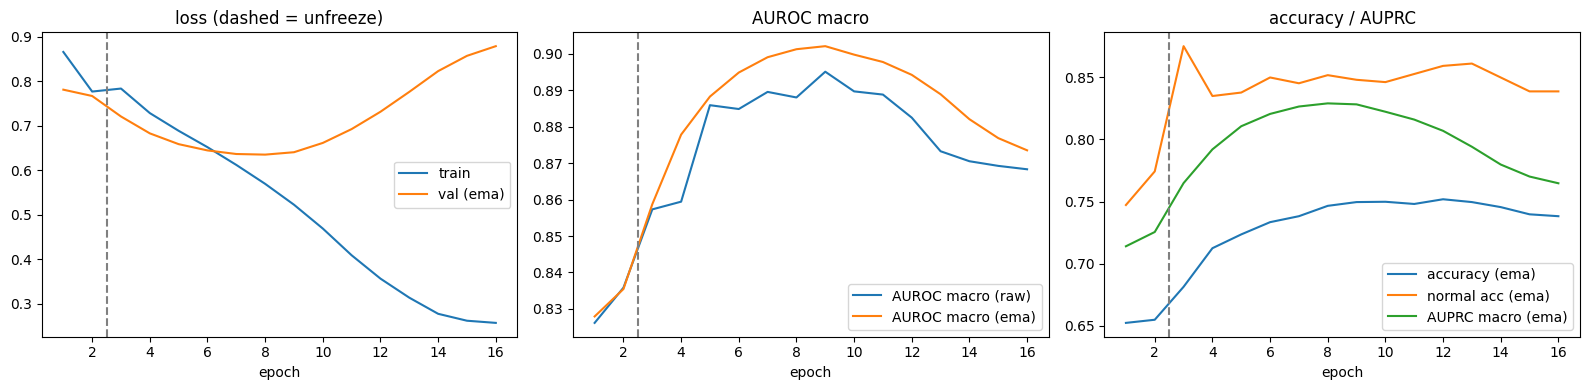

In [26]:
steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)

history = []
best_auroc, best_epoch, best_which = -1.0, 0, ""
best_state, best_m = None, None

def run_phase(tag, optimizer, scheduler, epochs, first_epoch):
    global best_auroc, best_epoch, best_which, best_state, best_m
    for epoch in range(first_epoch, first_epoch + epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(epoch, optimizer, scheduler)

        # evaluate RAW weights
        vl_raw, y_true, probs = evaluate(val_loader, desc=f"ep {epoch:02d} [raw]")
        m_raw = compute_metrics(y_true, probs)

        # evaluate EMA weights (stash raw -> swap -> eval -> restore)
        stash = {k: v.detach().clone() for k, v in model.state_dict().items()}
        model.load_state_dict(ema.shadow)
        vl_ema, y_true, probs = evaluate(val_loader, desc=f"ep {epoch:02d} [ema]")
        m_ema = compute_metrics(y_true, probs)
        model.load_state_dict(stash)

        print(f"[{tag}] epoch {epoch:02d} | {(time.time()-t0)/60:5.1f} min | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss: raw {vl_raw:.4f} / ema {vl_ema:.4f}")
        print(f"         raw: AUROC macro {m_raw['auroc_macro']:.4f} | acc {m_raw['accuracy']:.4f}")
        print_metrics(m_ema, prefix="         ema: ")

        history.append({"epoch": epoch, "phase": tag, "train_loss": tr_loss,
                        "train_acc": tr_acc, "val_loss": vl_ema,
                        "auroc_raw": m_raw["auroc_macro"], "auroc_ema": m_ema["auroc_macro"],
                        "auprc_ema": m_ema["auprc_macro"], "acc_ema": m_ema["accuracy"],
                        "acc_normal_ema": m_ema["acc_normal"]})

        # best model = better of raw / EMA, by macro AUROC
        cand, which, src = ((m_ema, "ema", ema.shadow) if m_ema["auroc_macro"] >= m_raw["auroc_macro"]
                            else (m_raw, "raw", stash))
        if cand["auroc_macro"] > best_auroc:
            best_auroc, best_epoch, best_which, best_m = cand["auroc_macro"], epoch, which, cand
            best_state = {k: v.detach().cpu().clone() for k, v in src.items()}

# ---------- phase 1: head only, backbone frozen (2 epochs) ----------
model.backbone.requires_grad_(False)
opt_head = build_optimizer()                       # only head params -> all @ LR_HEAD
sched_head = make_scheduler(opt_head, WARMUP_HEAD, steps_per_epoch * HEAD_EPOCHS)
run_phase("head-only", opt_head, sched_head, HEAD_EPOCHS, 1)

# ---------- phase 2: fine-tune everything with LLRD (20 epochs) ----------
model.backbone.requires_grad_(True)
opt_ft = build_optimizer()                         # head @ LR_HEAD, stages @ LLRD
sched_ft = make_scheduler(opt_ft, WARMUP_FT, steps_per_epoch * FT_EPOCHS)
run_phase("fine-tune", opt_ft, sched_ft, FT_EPOCHS, HEAD_EPOCHS + 1)

torch.save(best_state, "/kaggle/working/best.pt")   # saved once, at the end
if device.type == "cuda":
    torch.cuda.empty_cache()

# ---------- final report on the best weights (with TTA) ----------
model.load_state_dict(best_state)
val_loss, y_true, probs = evaluate(val_loader, desc="best model [TTA]" if TTA else "best model", tta=TTA)
m = compute_metrics(y_true, probs)
if device.type == "cuda":
    torch.cuda.empty_cache()

print(f"\nBEST MODEL (epoch {best_epoch}, {best_which} weights) - saved to /kaggle/working/best.pt")
print(f"final evaluation with TTA={TTA}")
print("-" * 60)
for k, v in m.items():
    if k != "confusion_matrix":
        print(f"{k:<18} {v:.4f}")
print("-" * 60)
print(pd.DataFrame(m["confusion_matrix"],
                   index=[f"true_{n}" for n in LABEL_NAMES],
                   columns=[f"pred_{n}" for n in LABEL_NAMES]))

hist = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(hist.epoch, hist.train_loss, label="train"); ax[0].plot(hist.epoch, hist.val_loss, label="val (ema)")
ax[0].axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--"); ax[0].set_title("loss (dashed = unfreeze)")
ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist.epoch, hist.auroc_raw, label="AUROC macro (raw)")
ax[1].plot(hist.epoch, hist.auroc_ema, label="AUROC macro (ema)")
ax[1].axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--"); ax[1].set_title("AUROC macro")
ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot(hist.epoch, hist.acc_ema, label="accuracy (ema)")
ax[2].plot(hist.epoch, hist.acc_normal_ema, label="normal acc (ema)")
ax[2].plot(hist.epoch, hist.auprc_ema, label="AUPRC macro (ema)")
ax[2].axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--"); ax[2].set_title("accuracy / AUPRC")
ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()